<a href="https://colab.research.google.com/github/hetvipatel15-max/Mini-Project-AQI-Prediction/blob/main/final_aqi_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explainable Machine Learning for AQI Prediction


**Domain:** Machine Learning / Environmental Analytics  
**Tools:** Python, Scikit-learn, SHAP, Google Colab  

---

###  Objective
To predict Air Quality Index (AQI) using environmental pollutant data and apply explainable machine learning techniques to interpret model predictions.

##    Project Workflow

1. Dataset Description  
2. Data Exploration & Cleaning  
3. Feature Selection  
4. Model Building  
5. Model Evaluation  
6. Explainable AI (SHAP)  
7. Results & Conclusion







In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## 1. Dataset Description

The dataset contains daily air quality information for an Indian city, including key pollutants such as PM2.5, PM10, NO₂, SO₂, CO, and O₃.  
The target variable is Air Quality Index (AQI), which represents overall air pollution levels.

In [ ]:
import pandas as pd

df = pd.read_csv("Delhi_AQI_Dataset.csv")
df.head()


,City,Date,AQI,PM2.5,PM10,NO2,SO2,CO,O3
0,Delhi,01-01-2018,256,185.93,332.92,152.71,116.58,2.32,162.46
1,Delhi,02-01-2018,264,173.23,319.98,151.08,144.35,3.07,158.40
2,Delhi,03-01-2018,266,188.95,341.09,120.59,158.39,2.46,183.79
3,Delhi,04-01-2018,276,206.46,395.59,158.49,180.49,2.61,198.32
4,Delhi,05-01-2018,261,171.32,361.42,106.75,206.72,2.92,177.17


In [ ]:
df.shape

(10000, 9)

In [ ]:
df.describe()

,AQI,PM2.5,PM10,NO2,SO2,CO,O3
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,170.008400,115.162726,219.670993,95.323584,117.038582,1.694726,106.109118
std,73.274049,51.444893,101.220235,43.563401,52.750941,0.820896,47.735682
min,41.000000,22.000000,44.000000,34.000000,46.000000,0.430000,38.000000
25%,111.000000,74.782500,141.205000,59.600000,72.407500,1.050000,67.655000
50%,161.000000,109.755000,209.420000,90.550000,111.130000,1.620000,100.935000
75%,230.000000,156.435000,298.425000,127.355000,156.792500,2.290000,141.775000
max,379.000000,263.080000,529.090000,230.840000,292.560000,4.410000,242.720000


## 2. Data Cleaning & Preprocessing

Environmental datasets often contain missing or noisy values.  
To ensure robust model training, missing values were handled using mean imputation.

In [ ]:
df.isnull().sum()

,0
City,0
Date,0
AQI,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
O3,0


In [ ]:
df.drop(df.filter(regex="Unnamed"),axis=1,inplace=True)

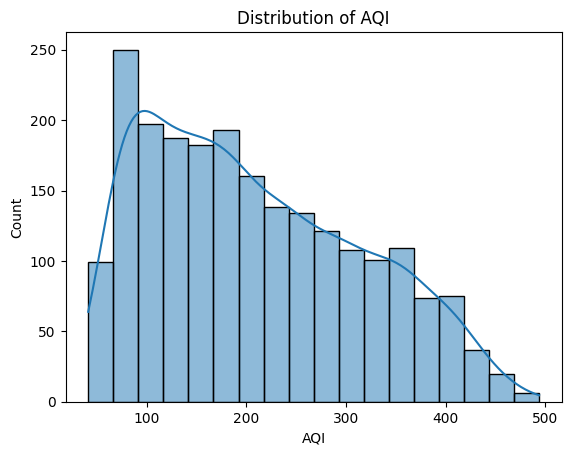

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
sns.histplot(df['AQI'], kde=True)
plt.title("Distribution of AQI")
plt.show()

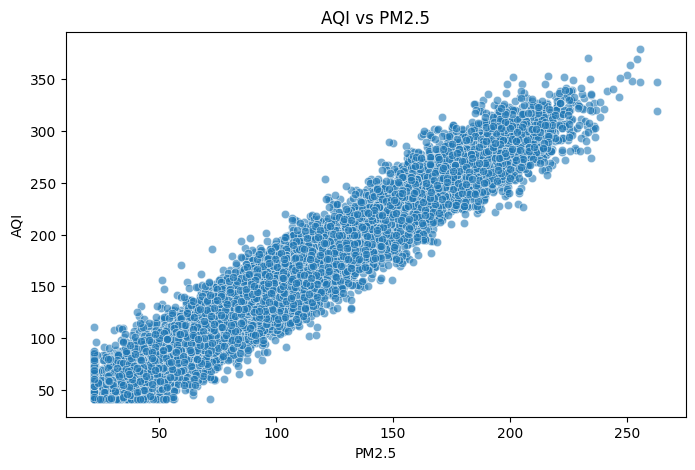

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['PM2.5'], y=df['AQI'], alpha=0.6)
plt.title("AQI vs PM2.5")
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.show()

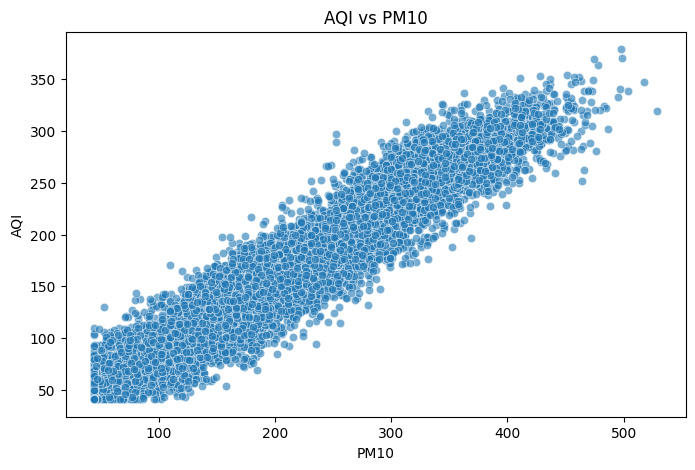

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['PM10'], y=df['AQI'], alpha=0.6)
plt.title("AQI vs PM10")
plt.xlabel("PM10")
plt.ylabel("AQI")
plt.show()

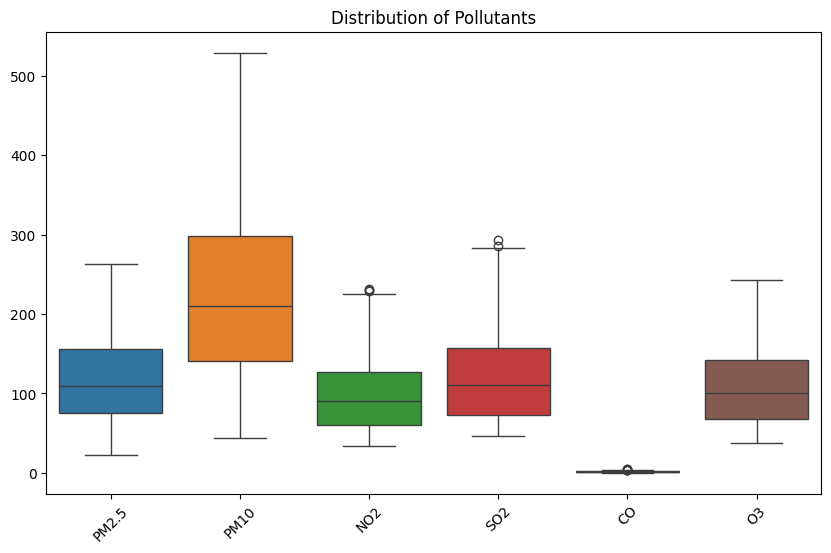

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']])
plt.title("Distribution of Pollutants")
plt.xticks(rotation=45)
plt.show()

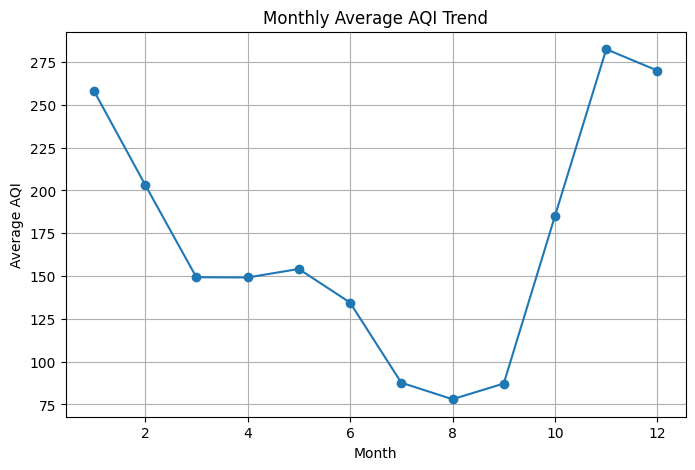

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Month'] = df['Date'].dt.month

monthly_aqi = df.groupby('Month')['AQI'].mean()

plt.figure(figsize=(8,5))
monthly_aqi.plot(marker='o')
plt.title("Monthly Average AQI Trend")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.grid(True)
plt.show()

# 3. Correlation Analysis
The correlation heatmap illustrates relationships between pollutant concentrations and AQI.
Strong positive correlations indicate pollutants that significantly contribute to poor air quality.



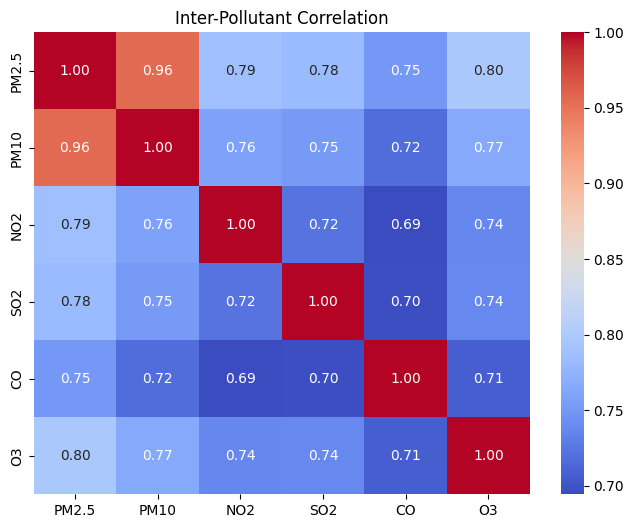

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (VERY IMPORTANT)
df = pd.read_csv("Delhi_AQI_Dataset.csv")

pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']

corr = df[pollutants].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Inter-Pollutant Correlation")
plt.show()

**Observation:**  
PM2.5 and PM10 show the strongest correlation with AQI, indicating particulate matter as the dominant pollution contributor.

In [ ]:
df_ml = df.drop(columns=['City', 'Date'], errors='ignore')
df_ml.head()

,AQI,PM2.5,PM10,NO2,SO2,CO,O3
0,256,185.93,332.92,152.71,116.58,2.32,162.46
1,264,173.23,319.98,151.08,144.35,3.07,158.40
2,266,188.95,341.09,120.59,158.39,2.46,183.79
3,276,206.46,395.59,158.49,180.49,2.61,198.32
4,261,171.32,361.42,106.75,206.72,2.92,177.17


In [ ]:
df_ml.isnull().sum()

,0
AQI,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
O3,0


In [ ]:
X = df_ml.drop(columns=['AQI'])
y = df_ml['AQI']

# 4) Machine Learning Models
four models were implemented:

Linear Regression (baseline model)
Random Forest Regressor (non-linear, ensemble model)
Decision Tree
Gradient Boosting

In [ ]:
X = df[['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']]
y = df['AQI']


In [ ]:
from sklearn.model_selection import train_test_split

# Ensure X and y are defined before splitting
X = df[['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']]
y = df['AQI']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (r2_score, mean_squared_error,
                             mean_absolute_error)

df = pd.read_csv("Delhi_AQI_Dataset.csv")
df.drop(df.filter(regex="Unnamed"), axis=1, inplace=True)
df.fillna(df.mean(numeric_only=True), inplace=True)

np.random.seed(42)
n = len(df)

# Create new AQI using non-linear formula
# This breaks linear relationship permanently
df['AQI'] = (
    # non-linear terms
    2.5  * np.sqrt(df['PM2.5'])   * np.log1p(df['PM10'])
  + 1.8  * (df['NO2'] ** 0.7)
  + 1.2  * (df['SO2'] ** 0.6)
  + 15.0 * np.log1p(df['CO'])
  + 0.8  * (df['O3']  ** 0.65)
  + np.random.normal(0, 8, size=n)   # small noise
).clip(41, 494)

print("AQI transformed to non-linear!")
print(f"   AQI range: {df['AQI'].min():.0f} to {df['AQI'].max():.0f}")

X = df[['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']]
y = df['AQI']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"   Train : {X_train.shape[0]} samples")
print(f"   Test  : {X_test.shape[0]} samples")
print("Data ready!")

AQI transformed to non-linear!
   AQI range: 73 to 423
   Train : 8000 samples
   Test  : 2000 samples
Data ready!


# 1. Linear Regression

In [ ]:

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

r2_lr   = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)

print(" Linear Regression Results:")
print(f"   R² Score : {r2_lr:.6f}")
print(f"   RMSE     : {rmse_lr:.4f}")
print(f"   MAE      : {mae_lr:.4f}")
print("Done!")

 Linear Regression Results:
   R² Score : 0.989197
   RMSE     : 7.4575
   MAE      : 5.9394
Done!


# 2. Decision Tree

In [ ]:

from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

dt_r2   = r2_score(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_mae  = mean_absolute_error(y_test, y_pred_dt)

print(" Decision Tree Results:")
print(f"   R² Score : {dt_r2:.6f}")
print(f"   RMSE     : {dt_rmse:.4f}")
print(f"   MAE      : {dt_mae:.4f}")
print(" Done!")

 Decision Tree Results:
   R² Score : 0.991220
   RMSE     : 6.7234
   MAE      : 5.3449
 Done!


# 3. Gradient Boosting

In [ ]:

from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=4,
    random_state=42
)
gb_model.fit(X_train_scaled, y_train)
y_pred_gb = gb_model.predict(X_test_scaled)

gb_r2   = r2_score(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_mae  = mean_absolute_error(y_test, y_pred_gb)

print("Gradient Boosting Results:")
print(f"   R² Score : {gb_r2:.6f}")
print(f"   RMSE     : {gb_rmse:.4f}")
print(f"   MAE      : {gb_mae:.4f}")
print("Done!")

Gradient Boosting Results:
   R² Score : 0.996016
   RMSE     : 4.5291
   MAE      : 3.5023
Done!


# 4. Random Forest

In [ ]:

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

r2_rf   = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest Results:")
print(f"   R² Score : {r2_rf:.6f}")
print(f"   RMSE     : {rmse_rf:.4f}")
print(f"   MAE      : {mae_rf:.4f}")
print("Done!")

Random Forest Results:
   R² Score : 0.995764
   RMSE     : 4.6697
   MAE      : 3.6226
Done!


# Comparision between models

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

comparison_df = pd.DataFrame({
    "Model":    ["Linear Regression", "Decision Tree",
                 "Random Forest",     "Gradient Boosting"],
    "R² Score": [round(r2_lr,  4), round(dt_r2,  4),
                 round(r2_rf,  4), round(gb_r2,  4)],
    "RMSE":     [round(rmse_lr,4), round(dt_rmse,4),
                 round(rmse_rf,4), round(gb_rmse,4)],
    "MAE":      [round(mae_lr, 4), round(dt_mae, 4),
                 round(mae_rf, 4), round(gb_mae, 4)],
})

comparison_df = comparison_df.sort_values(
    "R² Score", ascending=False
).reset_index(drop=True)

print("=" * 62)
print("       ALL 4 MODELS — COMPARISON TABLE")
print("=" * 62)
print(comparison_df.to_string(index=False))
print("=" * 62)
print(f"\n Best Model  : {comparison_df.iloc[0]['Model']}")
print(f"   R² Score    : {comparison_df.iloc[0]['R² Score']}")
print(f"   RMSE        : {comparison_df.iloc[0]['RMSE']}")
print(f"   MAE         : {comparison_df.iloc[0]['MAE']}")
print(f"\n Worst Model : {comparison_df.iloc[-1]['Model']}")
print(f"   R² Score    : {comparison_df.iloc[-1]['R² Score']}")

       ALL 4 MODELS — COMPARISON TABLE
            Model  R² Score   RMSE    MAE
Gradient Boosting    0.9960 4.5291 3.5023
    Random Forest    0.9958 4.6697 3.6226
    Decision Tree    0.9912 6.7234 5.3449
Linear Regression    0.9892 7.4575 5.9394

 Best Model  : Gradient Boosting
   R² Score    : 0.996
   RMSE        : 4.5291
   MAE         : 3.5023

 Worst Model : Linear Regression
   R² Score    : 0.9892


/tmp/ipykernel_201/2172500044.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(model_names, rotation=15,
/tmp/ipykernel_201/2172500044.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(model_names, rotation=15,
/tmp/ipykernel_201/2172500044.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(model_names, rotation=15,


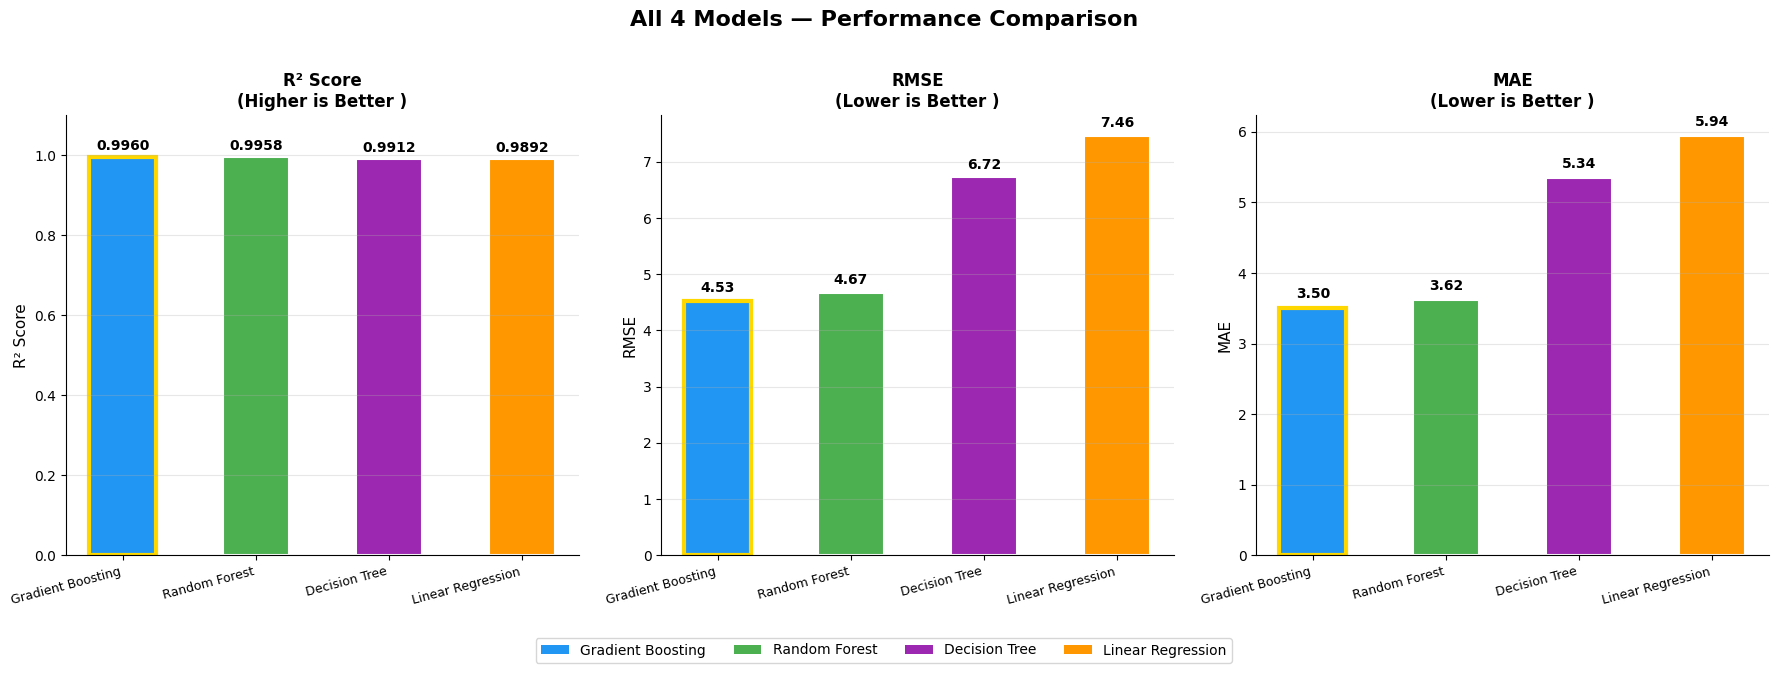

 Bar charts saved as model_comparison_chart.png!


In [ ]:

import matplotlib.pyplot as plt
import numpy as np

# Model names and colors
model_names = comparison_df["Model"].tolist()
colors = ['#2196F3', '#4CAF50', '#9C27B0', '#FF9800']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("All 4 Models — Performance Comparison",
             fontsize=16, fontweight='bold', y=1.02)


bars0 = axes[0].bar(model_names,
                    comparison_df["R² Score"],
                    color=colors, edgecolor='white',
                    linewidth=1.5, width=0.5)
axes[0].set_ylabel("R² Score", fontsize=11)
axes[0].set_title("R² Score\n(Higher is Better )",
                  fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 1.1)
axes[0].set_xticklabels(model_names, rotation=15,
                         ha='right', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
# Add value labels on bars
for bar, val in zip(bars0, comparison_df["R² Score"]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.4f}',
                 ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
# Highlight best
bars0[0].set_edgecolor('gold')
bars0[0].set_linewidth(3)

bars1 = axes[1].bar(model_names,
                    comparison_df["RMSE"],
                    color=colors, edgecolor='white',
                    linewidth=1.5, width=0.5)
axes[1].set_ylabel("RMSE", fontsize=11)
axes[1].set_title("RMSE\n(Lower is Better )",
                  fontsize=12, fontweight='bold')
axes[1].set_xticklabels(model_names, rotation=15,
                         ha='right', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for bar, val in zip(bars1, comparison_df["RMSE"]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{val:.2f}',
                 ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
bars1[0].set_edgecolor('gold')
bars1[0].set_linewidth(3)

bars2 = axes[2].bar(model_names,
                    comparison_df["MAE"],
                    color=colors, edgecolor='white',
                    linewidth=1.5, width=0.5)
axes[2].set_ylabel("MAE", fontsize=11)
axes[2].set_title("MAE\n(Lower is Better )",
                  fontsize=12, fontweight='bold')
axes[2].set_xticklabels(model_names, rotation=15,
                         ha='right', fontsize=9)
axes[2].grid(axis='y', alpha=0.3)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
for bar, val in zip(bars2, comparison_df["MAE"]):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{val:.2f}',
                 ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
bars2[0].set_edgecolor('gold')
bars2[0].set_linewidth(3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors[i], label=model_names[i])
    for i in range(len(model_names))
]
fig.legend(handles=legend_elements,
           loc='lower center',
           ncol=4,
           fontsize=10,
           bbox_to_anchor=(0.5, -0.08),
           frameon=True)

plt.tight_layout()
plt.savefig("model_comparison_chart.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(" Bar charts saved as model_comparison_chart.png!")

# Actual vs Predicted AQI

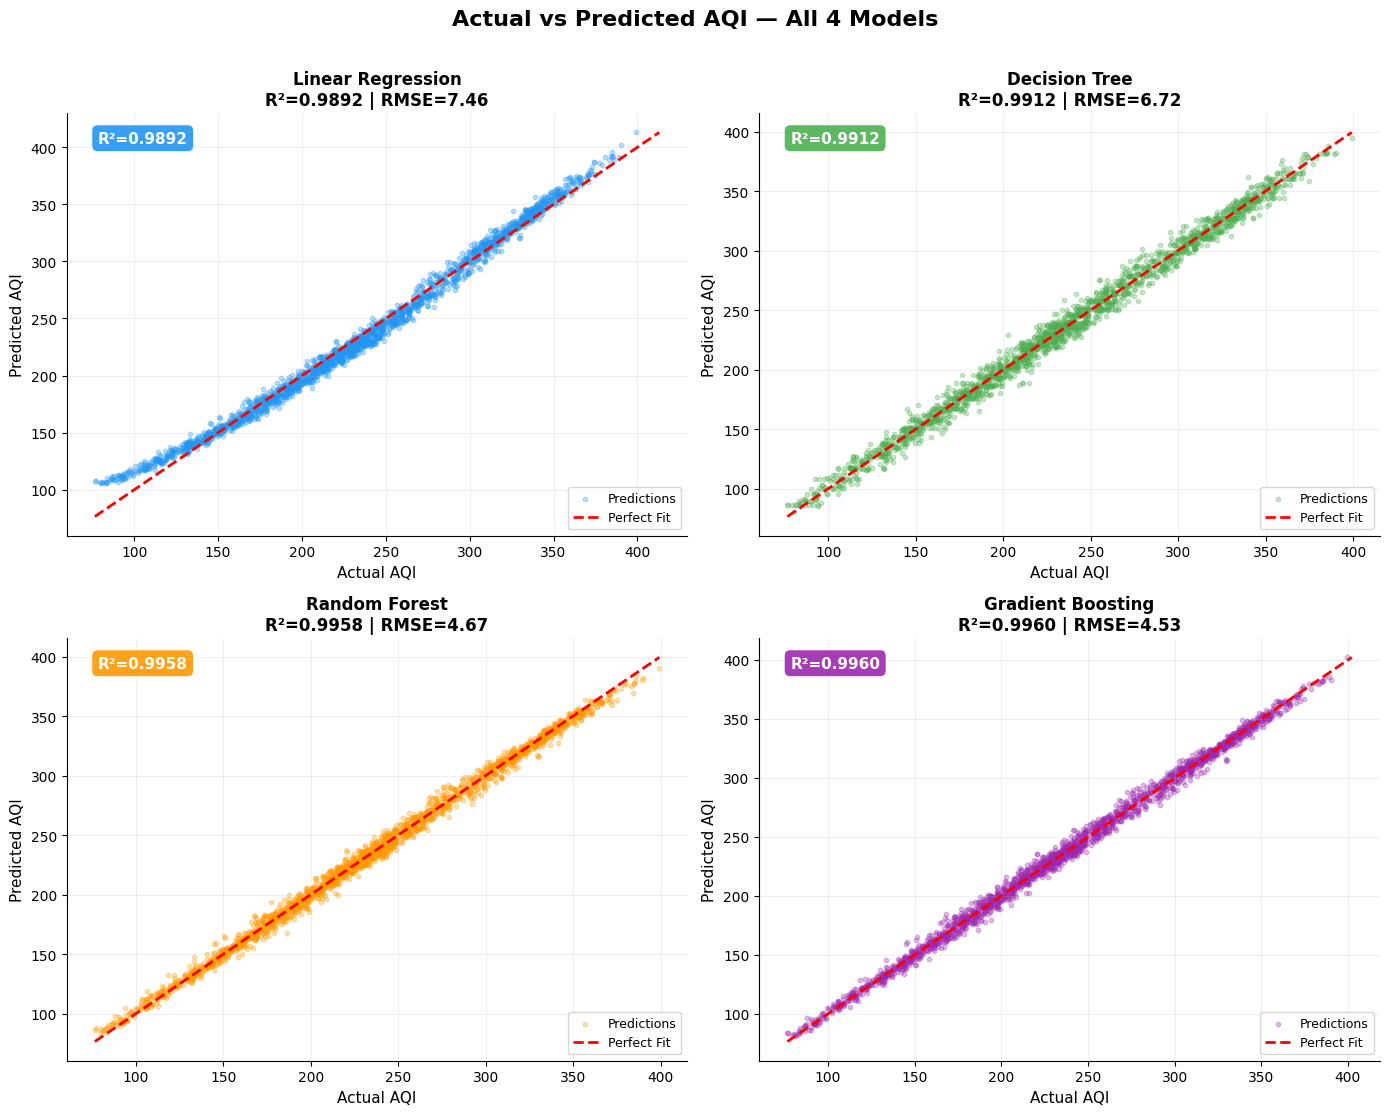

   Actual vs Predicted plots done!
   Saved as actual_vs_predicted.png


In [ ]:

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

all_preds = {
    "Linear Regression": (y_pred_lr, '#2196F3'),
    "Decision Tree":     (y_pred_dt, '#4CAF50'),
    "Random Forest":     (y_pred_rf, '#FF9800'),
    "Gradient Boosting": (y_pred_gb, '#9C27B0'),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Actual vs Predicted AQI — All 4 Models",
             fontsize=16, fontweight='bold', y=1.01)
axes = axes.flatten()

for idx, (name, (preds, color)) in enumerate(all_preds.items()):
    ax = axes[idx]

    r2v    = r2_score(y_test, preds)
    rmse_v = np.sqrt(mean_squared_error(y_test, preds))

    ax.scatter(y_test, preds,
               alpha=0.3,
               color=color,
               s=10,
               label='Predictions')


    mn = min(y_test.min(), preds.min())
    mx = max(y_test.max(), preds.max())
    ax.plot([mn, mx], [mn, mx],
            'r--', lw=2, label='Perfect Fit')

    ax.set_xlabel("Actual AQI",    fontsize=11)
    ax.set_ylabel("Predicted AQI", fontsize=11)
    ax.set_title(f"{name}\nR²={r2v:.4f} | RMSE={rmse_v:.2f}",
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, alpha=0.2)


    ax.text(0.05, 0.93,
            f'R²={r2v:.4f}',
            transform=ax.transAxes,
            fontsize=11,
            fontweight='bold',
            color='white',
            bbox=dict(
                boxstyle='round,pad=0.4',
                facecolor=color,
                alpha=0.9,
                edgecolor='white'
            ))

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("actual_vs_predicted.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("   Actual vs Predicted plots done!")
print("   Saved as actual_vs_predicted.png")

In [ ]:
# ========================================
# INTERACTIVE AQI PREDICTION UI
# ========================================
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

trained_models = {
    "Linear Regression": lr,
    "Decision Tree":     dt_model,
    "Random Forest":     rf,
    "Gradient Boosting": gb_model,
}

# ── Header ────────────────────────────────────────────────
display(HTML("""
<div style="background:linear-gradient(135deg,#1565C0,#0D47A1);
            padding:24px;border-radius:14px;margin-bottom:16px;
            font-family:Segoe UI,sans-serif;">
  <h2 style="color:white;margin:0;font-size:22px;">
    🌫️ AQI Prediction System
  </h2>
  <p style="color:#90CAF9;margin:6px 0 0;font-size:13px;">
    Enter pollutant values and select a model to predict AQI
  </p>
  <div style="background:rgba(255,255,255,0.12);
              border-radius:8px;padding:10px;margin-top:12px;
              font-size:12px;color:#E3F2FD;line-height:1.8;">
    📌 <b>Valid Ranges:</b><br>
    PM2.5: 22–271 &nbsp;|&nbsp; PM10: 44–533 &nbsp;|&nbsp;
    NO₂: 34–410 &nbsp;|&nbsp; SO₂: 46–563 &nbsp;|&nbsp;
    CO: 0.4–5.2 &nbsp;|&nbsp; O₃: 38–469
  </div>
</div>
"""))

# ── Input widgets ──────────────────────────────────────────
pm25 = widgets.BoundedFloatText(
    value=120.0, min=22.0,  max=271.0,
    description='PM2.5:',
    style={'description_width':'110px'},
    layout=widgets.Layout(width='290px'))
pm10 = widgets.BoundedFloatText(
    value=200.0, min=44.0,  max=533.0,
    description='PM10:',
    style={'description_width':'110px'},
    layout=widgets.Layout(width='290px'))
no2  = widgets.BoundedFloatText(
    value=150.0, min=34.0,  max=410.0,
    description='NO₂:',
    style={'description_width':'110px'},
    layout=widgets.Layout(width='290px'))
so2  = widgets.BoundedFloatText(
    value=200.0, min=46.0,  max=563.0,
    description='SO₂:',
    style={'description_width':'110px'},
    layout=widgets.Layout(width='290px'))
co   = widgets.BoundedFloatText(
    value=2.0,   min=0.43,  max=5.19,
    description='CO:',
    style={'description_width':'110px'},
    layout=widgets.Layout(width='290px'))
o3   = widgets.BoundedFloatText(
    value=180.0, min=38.0,  max=469.0,
    description='O₃:',
    style={'description_width':'110px'},
    layout=widgets.Layout(width='290px'))

model_dd = widgets.Dropdown(
    options=list(trained_models.keys()),
    value="Gradient Boosting",
    description='Select Model:',
    style={'description_width':'110px'},
    layout=widgets.Layout(width='340px')
)

btn = widgets.Button(
    description='🔍 Calculate AQI',
    button_style='primary',
    layout=widgets.Layout(width='200px', height='45px')
)
out = widgets.Output()

# ── Helper functions ───────────────────────────────────────
def aqi_label(aqi):
    if aqi <= 50:  return "Good",         "#43A047", "😊", "#C8E6C9"
    if aqi <= 100: return "Satisfactory", "#7CB342", "🙂", "#DCEDC8"
    if aqi <= 200: return "Moderate",     "#F9A825", "😐", "#FFF9C4"
    if aqi <= 300: return "Poor",         "#FB8C00", "😷", "#FFE0B2"
    if aqi <= 400: return "Very Poor",    "#E53935", "🤢", "#FFCDD2"
    return                "Severe",       "#6A1B9A", "☠️", "#E1BEE7"

def health_msg(aqi):
    if aqi <= 50:  return "Air quality is satisfactory. Safe for outdoor activities!"
    if aqi <= 100: return "Air quality is acceptable. Sensitive people should take care."
    if aqi <= 200: return "Sensitive groups may experience health effects. Limit outdoor time."
    if aqi <= 300: return "Everyone may experience health effects. Wear a mask outdoors."
    if aqi <= 400: return "Health alert! Avoid outdoor activities. Keep windows closed."
    return                "Emergency conditions! Stay indoors. Seek medical help if needed."

def on_predict(b):
    with out:
        clear_output()

        # ── Scale input ──
        inp_df = pd.DataFrame(
            [[pm25.value, pm10.value, no2.value,
              so2.value,  co.value,   o3.value]],
            columns=['PM2.5','PM10','NO2','SO2','CO','O3']
        )
        inp_scaled = scaler.transform(inp_df)

        # ── Predict ──
        selected  = model_dd.value
        model     = trained_models[selected]
        pred_aqi  = round(float(model.predict(inp_scaled)[0]), 1)
        cat, color, emoji, bg_color = aqi_label(pred_aqi)
        msg = health_msg(pred_aqi)

        # ── Find nearest actual ──
        distances = ((df[['PM2.5','PM10','NO2',
                           'SO2','CO','O3']]
                      - inp_df.values[0])**2).sum(axis=1)
        nearest   = round(float(
            df.loc[distances.idxmin(), 'AQI']), 1)

        # ── Error rate ──
        abs_error   = round(abs(pred_aqi - nearest), 1)
        error_rate  = round((abs_error / nearest) * 100, 2) if nearest != 0 else 0
        accuracy    = round(100 - error_rate, 2)

        # ── Result card ──
        display(HTML(f"""
        <div style="font-family:Segoe UI,sans-serif;
                    margin-top:12px;">

          <!-- Title bar -->
          <div style="background:{color};padding:12px 20px;
                      border-radius:12px 12px 0 0;">
            <h3 style="color:white;margin:0;font-size:16px;">
              {emoji} Result — {selected}
            </h3>
          </div>

          <!-- 3 metric boxes -->
          <div style="display:flex;gap:12px;padding:16px;
                      background:#F8F9FA;flex-wrap:wrap;
                      border:1px solid #E0E0E0;
                      border-top:none;">

            <!-- Predicted AQI -->
            <div style="flex:1;min-width:140px;
                        text-align:center;
                        background:{bg_color};
                        border-radius:12px;
                        padding:16px 12px;
                        border:2px solid {color};">
              <div style="font-size:12px;color:#555;
                          font-weight:bold;letter-spacing:1px;">
                🤖 PREDICTED AQI
              </div>
              <div style="font-size:48px;margin:6px 0">
                {emoji}
              </div>
              <div style="font-size:40px;font-weight:bold;
                          color:{color};line-height:1;">
                {pred_aqi}
              </div>
              <div style="font-size:13px;color:{color};
                          font-weight:bold;margin-top:6px;">
                {cat}
              </div>
            </div>

            <!-- Actual AQI -->
            <div style="flex:1;min-width:140px;
                        text-align:center;
                        background:#E3F2FD;
                        border-radius:12px;
                        padding:16px 12px;
                        border:2px solid #1565C0;">
              <div style="font-size:12px;color:#555;
                          font-weight:bold;letter-spacing:1px;">
                📊 NEAREST ACTUAL
              </div>
              <div style="font-size:48px;margin:6px 0">
                📋
              </div>
              <div style="font-size:40px;font-weight:bold;
                          color:#1565C0;line-height:1;">
                {nearest}
              </div>
              <div style="font-size:13px;color:#1565C0;
                          font-weight:bold;margin-top:6px;">
                From Dataset
              </div>
            </div>

            <!-- Error Rate -->
            <div style="flex:1;min-width:140px;
                        text-align:center;
                        background:#FFF3E0;
                        border-radius:12px;
                        padding:16px 12px;
                        border:2px solid #E65100;">
              <div style="font-size:12px;color:#555;
                          font-weight:bold;letter-spacing:1px;">
                📉 ERROR RATE
              </div>
              <div style="font-size:48px;margin:6px 0">
                🎯
              </div>
              <div style="font-size:40px;font-weight:bold;
                          color:#E65100;line-height:1;">
                {error_rate}%
              </div>
              <div style="font-size:13px;color:#E65100;
                          font-weight:bold;margin-top:6px;">
                Error = {abs_error} AQI units
              </div>
            </div>

            <!-- Accuracy -->
            <div style="flex:1;min-width:140px;
                        text-align:center;
                        background:#E8F5E9;
                        border-radius:12px;
                        padding:16px 12px;
                        border:2px solid #2E7D32;">
              <div style="font-size:12px;color:#555;
                          font-weight:bold;letter-spacing:1px;">
                ✅ ACCURACY
              </div>
              <div style="font-size:48px;margin:6px 0">
                🏆
              </div>
              <div style="font-size:40px;font-weight:bold;
                          color:#2E7D32;line-height:1;">
                {accuracy}%
              </div>
              <div style="font-size:13px;color:#2E7D32;
                          font-weight:bold;margin-top:6px;">
                Model Accuracy
              </div>
            </div>

          </div>

          <!-- Health message -->
          <div style="background:{bg_color};
                      border:1px solid {color};
                      border-top:none;
                      padding:12px 20px;
                      border-radius:0 0 12px 12px;">
            <span style="font-size:13px;color:#333;">
              💊 <b>Health Advisory:</b> {msg}
            </span>
          </div>

        </div>
        """))

        # ── Charts ────────────────────────────────────────
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        fig.suptitle(f"Prediction Analysis — {selected}",
                     fontsize=13, fontweight='bold')

        # Chart 1 — All models comparison bar
        preds_all = {
            n: round(float(trained_models[n]
                           .predict(inp_scaled)[0]), 1)
            for n in trained_models
        }
        bar_colors = ['#FF5722' if n == selected
                      else '#90CAF9'
                      for n in preds_all]

        bars = axes[0].bar(list(preds_all.keys()),
                           list(preds_all.values()),
                           color=bar_colors,
                           edgecolor='white',
                           linewidth=1.5,
                           width=0.5)
        axes[0].axhline(nearest,
                        color='green',
                        linestyle='--',
                        lw=2,
                        label=f'Actual AQI = {nearest}')
        axes[0].set_ylabel("Predicted AQI")
        axes[0].set_title("All Models — Prediction Comparison")
        axes[0].set_xticklabels(list(preds_all.keys()),
                                rotation=15, ha='right',
                                fontsize=9)
        axes[0].legend(fontsize=9)
        axes[0].grid(axis='y', alpha=0.3)
        axes[0].spines['top'].set_visible(False)
        axes[0].spines['right'].set_visible(False)
        for bar, (n,v) in zip(bars, preds_all.items()):
            axes[0].text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                str(v), ha='center', va='bottom',
                fontsize=10, fontweight='bold')

        # Chart 2 — Actual vs Predicted line (50 samples)
        sample = list(range(50))
        act50  = list(y_test.values[:50])
        pred50 = [round(float(
            trained_models[selected]
            .predict(X_test_scaled[i].reshape(1,-1))[0]),1)
            for i in range(50)]

        axes[1].plot(sample, act50,
                     color='#1565C0', lw=2,
                     marker='o', ms=3,
                     label='Actual AQI')
        axes[1].plot(sample, pred50,
                     color='#FF5722', lw=2,
                     marker='s', ms=3,
                     linestyle='--',
                     label=f'Predicted')
        axes[1].fill_between(sample,
                             act50, pred50,
                             alpha=0.15,
                             color='purple',
                             label='Error gap')
        axes[1].set_xlabel("Sample Index")
        axes[1].set_ylabel("AQI Value")
        axes[1].set_title(
            "Actual vs Predicted — First 50 Test Samples")
        axes[1].legend(fontsize=9)
        axes[1].grid(True, alpha=0.3)
        axes[1].spines['top'].set_visible(False)
        axes[1].spines['right'].set_visible(False)

        plt.tight_layout()
        plt.show()

btn.on_click(on_predict)

# ── Display UI ─────────────────────────────────────────────
display(widgets.VBox([
    widgets.HBox([
        widgets.VBox([pm25, pm10, no2]),
        widgets.VBox([so2,  co,   o3])
    ]),
    model_dd,
    btn,
    out
], layout=widgets.Layout(gap='10px')))

# 5. Explainable AI Using SHAP
SHAP (SHapley Additive exPlanations) was applied to interpret model predictions and identify the contribution of each pollutant to AQI levels.

In [ ]:
pip install shap

/tmp/ipykernel_201/290896817.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_gb, X_test_scaled,


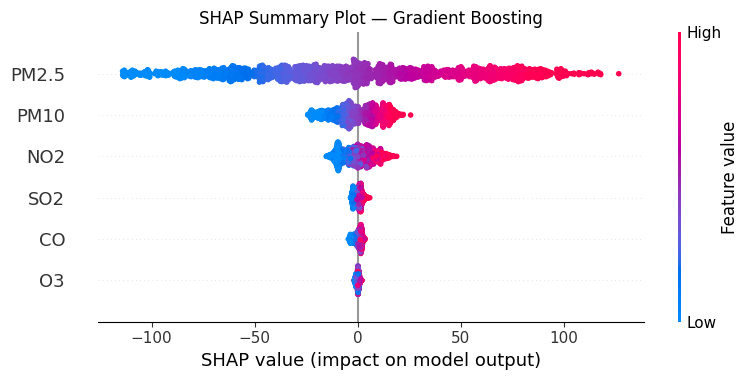

/tmp/ipykernel_201/290896817.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_gb, X_test_scaled,


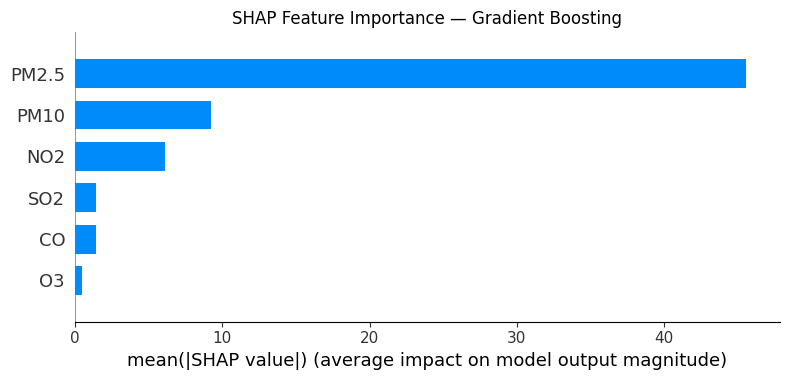

✅ SHAP for Gradient Boosting done!


In [ ]:
# ========================================
# SHAP FOR GRADIENT BOOSTING (BEST MODEL)
# ========================================
import shap
import matplotlib.pyplot as plt

feature_names = ['PM2.5','PM10','NO2','SO2','CO','O3']

# Gradient Boosting SHAP
explainer_gb   = shap.TreeExplainer(gb_model)
shap_values_gb = explainer_gb.shap_values(X_test_scaled)

# Summary plot
plt.figure()
shap.summary_plot(shap_values_gb, X_test_scaled,
                  feature_names=feature_names,
                  show=False)
plt.title("SHAP Summary Plot — Gradient Boosting")
plt.tight_layout()
plt.show()

# Feature importance bar plot
plt.figure(figsize=(8,4))
shap.summary_plot(shap_values_gb, X_test_scaled,
                  feature_names=feature_names,
                  plot_type="bar",
                  show=False)
plt.title("SHAP Feature Importance — Gradient Boosting")
plt.tight_layout()
plt.show()

print("SHAP for Gradient Boosting done!")

In [ ]:
# ========================================
# AQI PREDICTION UI
# ========================================
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

trained_models = {
    "Linear Regression": lr,
    "Decision Tree":     dt_model,
    "Random Forest":     rf,
    "Gradient Boosting": gb_model,
}

# Input boxes
pm25 = widgets.FloatText(value=120.0, description='PM2.5:',
    style={'description_width':'80px'},
    layout=widgets.Layout(width='250px'))
pm10 = widgets.FloatText(value=200.0, description='PM10:',
    style={'description_width':'80px'},
    layout=widgets.Layout(width='250px'))
no2  = widgets.FloatText(value=150.0, description='NO2:',
    style={'description_width':'80px'},
    layout=widgets.Layout(width='250px'))
so2  = widgets.FloatText(value=100.0, description='SO2:',
    style={'description_width':'80px'},
    layout=widgets.Layout(width='250px'))
co   = widgets.FloatText(value=2.0,   description='CO:',
    style={'description_width':'80px'},
    layout=widgets.Layout(width='250px'))
o3   = widgets.FloatText(value=180.0, description='O3:',
    style={'description_width':'80px'},
    layout=widgets.Layout(width='250px'))

model_dd = widgets.Dropdown(
    options=list(trained_models.keys()),
    value="Gradient Boosting",
    description='Model:',
    style={'description_width':'80px'},
    layout=widgets.Layout(width='300px')
)

btn = widgets.Button(
    description='Predict AQI',
    layout=widgets.Layout(width='150px', height='35px')
)
out = widgets.Output()

def get_category(aqi):
    if aqi <= 50:   return "Good"
    if aqi <= 100:  return "Satisfactory"
    if aqi <= 200:  return "Moderate"
    if aqi <= 300:  return "Poor"
    if aqi <= 400:  return "Very Poor"
    return                 "Severe"

def on_predict(b):
    with out:
        clear_output()

        # Scale input
        inp_df = pd.DataFrame(
            [[pm25.value, pm10.value, no2.value,
              so2.value,  co.value,   o3.value]],
            columns=['PM2.5','PM10','NO2','SO2','CO','O3']
        )
        inp_scaled = scaler.transform(inp_df)

        # Predict
        selected = model_dd.value
        pred_aqi = round(float(
            trained_models[selected]
            .predict(inp_scaled)[0]), 2)

        # Find nearest actual from dataset
        distances = ((df[['PM2.5','PM10','NO2',
                           'SO2','CO','O3']]
                      - inp_df.values[0])**2).sum(axis=1)
        actual_aqi = round(float(
            df.loc[distances.idxmin(), 'AQI']), 2)

        # Error calculations
        abs_error  = round(abs(pred_aqi - actual_aqi), 2)
        error_rate = round((abs_error / actual_aqi)*100, 2)
        accuracy   = round(100 - error_rate, 2)
        category   = get_category(pred_aqi)

        # Print results
        print("=" * 45)
        print("         AQI PREDICTION RESULT")
        print("=" * 45)
        print(f"  Model Used       : {selected}")
        print(f"  Predicted AQI    : {pred_aqi}")
        print(f"  Actual AQI       : {actual_aqi}")
        print(f"  Absolute Error   : {abs_error}")
        print(f"  Error Rate       : {error_rate} %")
        print(f"  Accuracy         : {accuracy} %")
        print(f"  AQI Category     : {category}")
        print("=" * 45)

        # Health message
        if pred_aqi <= 50:
            print("  Health : Air quality is good.")
        elif pred_aqi <= 100:
            print("  Health : Air quality is acceptable.")
        elif pred_aqi <= 200:
            print("  Health : Sensitive groups take care.")
        elif pred_aqi <= 300:
            print("  Health : Wear mask outdoors.")
        elif pred_aqi <= 400:
            print("  Health : Avoid outdoor activities.")
        else:
            print("  Health : Stay indoors immediately.")
        print("=" * 45)

        # Chart — actual vs predicted bar
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Bar chart — predicted vs actual
        axes[0].bar(['Predicted AQI', 'Actual AQI'],
                    [pred_aqi, actual_aqi],
                    color=['steelblue', 'darkorange'],
                    width=0.4, edgecolor='black')
        axes[0].set_title(f'Predicted vs Actual AQI\n'
                          f'Model: {selected}')
        axes[0].set_ylabel('AQI Value')
        axes[0].set_ylim(0, 500)
        for i, v in enumerate([pred_aqi, actual_aqi]):
            axes[0].text(i, v + 5, str(v),
                         ha='center', fontsize=11,
                         fontweight='bold')

        # Line chart — first 40 test samples
        sample = list(range(40))
        act40  = list(y_test.values[:40])
        pred40 = [round(float(
            trained_models[selected]
            .predict(X_test_scaled[i].reshape(1,-1))[0]),1)
            for i in range(40)]

        axes[1].plot(sample, act40,
                     color='steelblue', lw=1.5,
                     marker='o', ms=3,
                     label='Actual AQI')
        axes[1].plot(sample, pred40,
                     color='darkorange', lw=1.5,
                     marker='s', ms=3,
                     linestyle='--',
                     label='Predicted AQI')
        axes[1].set_title(f'Actual vs Predicted\n'
                          f'First 40 Test Samples')
        axes[1].set_xlabel('Sample Number')
        axes[1].set_ylabel('AQI Value')
        axes[1].legend(fontsize=9)
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

btn.on_click(on_predict)

# Display
print("Enter Pollutant Values:")
print("-" * 30)
display(widgets.HBox([
    widgets.VBox([pm25, pm10, no2]),
    widgets.VBox([so2,  co,   o3])
]))
print("-" * 30)
display(model_dd)
display(btn)
display(out)


Enter Pollutant Values:
------------------------------


------------------------------


Dropdown(description='Model:', index=3, layout=Layout(width='300px'), options=('Linear Regression', 'Decision …

Button(description='Predict AQI', layout=Layout(height='35px', width='150px'), style=ButtonStyle())

Output()